# Flight-Aware LoRa Link Adaptation

This notebook combines the previous tutorial layers into one decision loop:

```text
UAV geometry -> path loss and installation margin -> interference + noise
             -> predicted packet reliability -> SF/BW/CR/TX-power choice
```

Notebooks 0-6 used 2.44 GHz to compare LoRa and Wi-Fi mechanisms. From this notebook onward we use the repository's field-pilot profile: 923 MHz and the SX1262-style 125/250/500 kHz bandwidth family. This is a device-level simulation profile, not a claim of regional operating compliance.

The packet-delivery curve and coding gains below are transparent teaching surrogates. Replace them with measured PER curves or a verified packet receiver before making hardware claims.


## 1. Packet airtime is part of the decision

Higher SF and stronger coding can improve robustness, but they keep the channel and transmitter busy longer. The standard LoRa airtime calculation below includes preamble, explicit header, payload CRC, coding overhead, and low-data-rate optimization.


In [1]:
import math
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

C = 299_792_458.0
FC_HZ = 923e6
PAYLOAD_BYTES = 16
PREAMBLE_SYMBOLS = 8

def lora_time_on_air_s(sf, bandwidth_hz, coding_rate_index, payload_bytes=PAYLOAD_BYTES):
    if coding_rate_index not in (1, 2, 3, 4):
        raise ValueError("coding_rate_index 1..4 means CR 4/5..4/8")
    symbol_time_s = (1 << sf) / bandwidth_hz
    low_data_rate_optimization = int(symbol_time_s >= 0.016)
    numerator = 8 * payload_bytes - 4 * sf + 28 + 16  # explicit header and payload CRC
    denominator = 4 * (sf - 2 * low_data_rate_optimization)
    payload_symbols = 8 + max(math.ceil(numerator / denominator) * (coding_rate_index + 4), 0)
    return (PREAMBLE_SYMBOLS + 4.25 + payload_symbols) * symbol_time_s

baseline_airtime_s = lora_time_on_air_s(7, 125e3, 1)
assert np.isclose(baseline_airtime_s, 0.051456)
print(f"Baseline SF7/BW125/CR4/5 airtime: {1e3 * baseline_airtime_s:.3f} ms")


Baseline SF7/BW125/CR4/5 airtime: 51.456 ms


## 2. One ground node and one UAV route

The UAV flies a 2 km straight route at 30 m altitude and 4 m/s. A ground node is at the route centre. The channel uses a log-distance model, a fixed installation loss, and a smooth central obstruction penalty. These terms stand in for the calibrated Sionna RT or measured path gain from Notebooks 4-5.

Keeping the channel formula visible is important: adaptation cannot be more trustworthy than the channel and receiver models used to drive it.


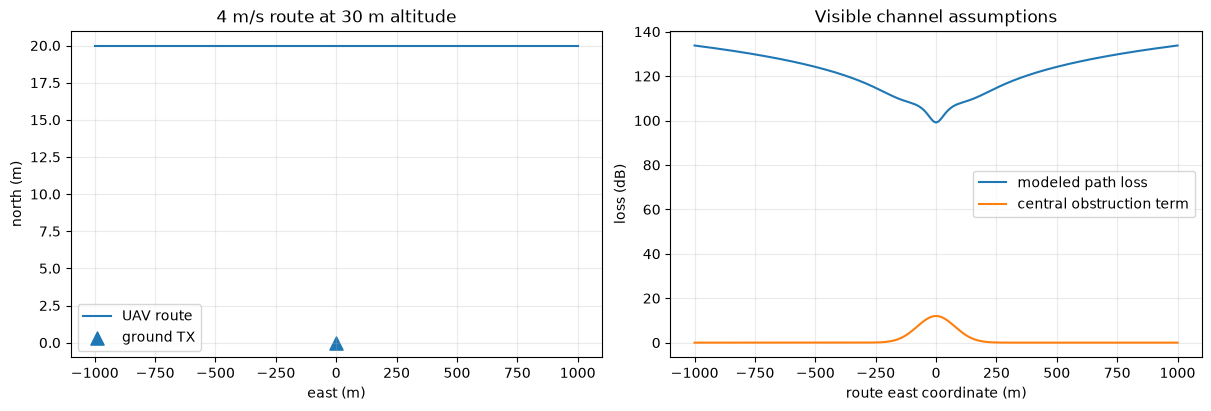

In [2]:
UAV_SPEED_MPS = 4.0
UAV_ALTITUDE_M = 30.0
GROUND_NODE = np.array([0.0, 0.0, 1.5])
ROUTE_X_M = np.linspace(-1000.0, 1000.0, 201)
ROUTE_Y_M = np.full_like(ROUTE_X_M, 20.0)
ROUTE_TIME_S = (ROUTE_X_M - ROUTE_X_M[0]) / UAV_SPEED_MPS

uav_position = np.column_stack([ROUTE_X_M, ROUTE_Y_M, np.full_like(ROUTE_X_M, UAV_ALTITUDE_M)])
distance_m = np.linalg.norm(uav_position - GROUND_NODE, axis=1)
free_space_loss_1m_db = 20 * np.log10(4 * np.pi * FC_HZ / C)
PATH_LOSS_EXPONENT = 3.2
INSTALLATION_LOSS_DB = 6.0
obstruction_loss_db = 12 * np.exp(-(ROUTE_X_M / 110)**2)
path_loss_db = (
    free_space_loss_1m_db
    + 10 * PATH_LOSS_EXPONENT * np.log10(np.maximum(distance_m, 1.0))
    + INSTALLATION_LOSS_DB
    + obstruction_loss_db
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(ROUTE_X_M, ROUTE_Y_M, label="UAV route")
axes[0].scatter(*GROUND_NODE[:2], marker="^", s=90, label="ground TX")
axes[0].set(title=f"{UAV_SPEED_MPS:g} m/s route at {UAV_ALTITUDE_M:g} m altitude", xlabel="east (m)", ylabel="north (m)")
axes[0].legend()
axes[1].plot(ROUTE_X_M, path_loss_db, label="modeled path loss")
axes[1].plot(ROUTE_X_M, obstruction_loss_db, label="central obstruction term")
axes[1].set(title="Visible channel assumptions", xlabel="route east coordinate (m)", ylabel="loss (dB)")
axes[1].legend()
plt.show()


## 3. Receiver disturbance and reliability surrogate

Thermal noise depends on bandwidth. We add the motor-on desensitization and residual external interference from Notebook 6 in linear power units. The required-SNR values and coding allowances are illustrative configuration thresholds, not universal sensitivity specifications.

Packet error probability is represented by a monotonic logistic curve around the resulting link margin. Its role is to expose the adaptation logic; measured PER versus SNR should replace it later.


In [3]:
NOISE_FIGURE_DB = 6.0
MOTOR_DESENSE_DB = 6.0
RESIDUAL_INTERFERENCE_DBM = (-128.0, -130.0)
REQUIRED_SNR_DB = {7: -7.5, 8: -10.0, 9: -12.5, 10: -15.0, 11: -17.5, 12: -20.0}
CODING_ALLOWANCE_DB = {1: 0.0, 4: 2.0}

def dbm_to_mw(power_dbm):
    return 10 ** (np.asarray(power_dbm) / 10)

def sum_dbm(power_values_dbm):
    return 10 * np.log10(np.sum(dbm_to_mw(power_values_dbm)))

def evaluate_configuration(path_loss, sf, bandwidth_hz, coding_rate_index, tx_power_dbm):
    noise_floor_dbm = -174 + 10 * np.log10(bandwidth_hz) + NOISE_FIGURE_DB + MOTOR_DESENSE_DB
    disturbance_dbm = sum_dbm((noise_floor_dbm, *RESIDUAL_INTERFERENCE_DBM))
    received_power_dbm = tx_power_dbm - path_loss
    snr_db = received_power_dbm - disturbance_dbm
    margin_db = snr_db - REQUIRED_SNR_DB[sf] + CODING_ALLOWANCE_DB[coding_rate_index]
    per = 1 / (1 + np.exp(margin_db / 1.7))
    airtime_s = lora_time_on_air_s(sf, bandwidth_hz, coding_rate_index)
    return {
        "received_power_dbm": received_power_dbm,
        "snr_db": snr_db,
        "margin_db": margin_db,
        "per": per,
        "airtime_s": airtime_s,
        "expected_attempts": 1 / np.maximum(1 - per, 1e-9),
    }


## 4. Select a configuration at each route position

The controller searches SF7-SF12, 125/250/500 kHz, CR4/5 or CR4/8, and 2/8/14 dBm. A configuration is feasible when predicted PER is at most 10% and nominal airtime is at most 0.5 s. Among feasible choices, it selects the shortest packet and then the lowest transmit power.

This objective is intentionally simple. A deployment may instead minimize battery energy, satisfy a legal channel-access constraint, reserve interference margin, or optimize complete collection probability.


In [4]:
TARGET_PER = 0.10
MAX_AIRTIME_S = 0.50
candidate_configurations = [
    (sf, bandwidth_hz, coding_rate_index, tx_power_dbm)
    for sf in range(7, 13)
    for bandwidth_hz in (125e3, 250e3, 500e3)
    for coding_rate_index in (1, 4)
    for tx_power_dbm in (2.0, 8.0, 14.0)
]

selected = []
for route_index, current_path_loss_db in enumerate(path_loss_db):
    feasible = []
    for sf, bandwidth_hz, coding_rate_index, tx_power_dbm in candidate_configurations:
        metrics = evaluate_configuration(current_path_loss_db, sf, bandwidth_hz, coding_rate_index, tx_power_dbm)
        if metrics["per"] <= TARGET_PER and metrics["airtime_s"] <= MAX_AIRTIME_S:
            feasible.append({
                "route_index": route_index,
                "sf": sf,
                "bandwidth_hz": bandwidth_hz,
                "coding_rate_index": coding_rate_index,
                "tx_power_dbm": tx_power_dbm,
                **metrics,
            })
    if not feasible:
        selected.append(None)
        continue
    selected.append(min(feasible, key=lambda item: (round(item["airtime_s"], 12), item["tx_power_dbm"], item["coding_rate_index"], -item["margin_db"])))

assert all(item is not None for item in selected)
selected_sf = np.array([item["sf"] for item in selected])
selected_bw_khz = np.array([item["bandwidth_hz"] / 1e3 for item in selected])
selected_cr = np.array([item["coding_rate_index"] for item in selected])
selected_tx_dbm = np.array([item["tx_power_dbm"] for item in selected])
selected_per = np.array([item["per"] for item in selected])
selected_attempts = np.array([item["expected_attempts"] for item in selected])

configuration_counts = Counter((item["sf"], int(item["bandwidth_hz"] / 1e3), item["coding_rate_index"], int(item["tx_power_dbm"])) for item in selected)
print(f"Used {len(configuration_counts)} of {len(candidate_configurations)} candidate configurations.")
for configuration, count in configuration_counts.most_common(8):
    sf, bw_khz, cr_index, tx_dbm = configuration
    print(f"SF{sf}, BW{bw_khz}, CR4/{cr_index + 4}, {tx_dbm} dBm: {count} route samples")


Used 19 of 108 candidate configurations.
SF7, BW500, CR4/5, 2 dBm: 35 route samples
SF7, BW500, CR4/5, 14 dBm: 32 route samples
SF7, BW500, CR4/5, 8 dBm: 24 route samples
SF9, BW250, CR4/8, 14 dBm: 20 route samples
SF8, BW500, CR4/8, 14 dBm: 14 route samples
SF7, BW500, CR4/8, 14 dBm: 14 route samples
SF9, BW500, CR4/8, 14 dBm: 10 route samples
SF9, BW125, CR4/5, 14 dBm: 8 route samples


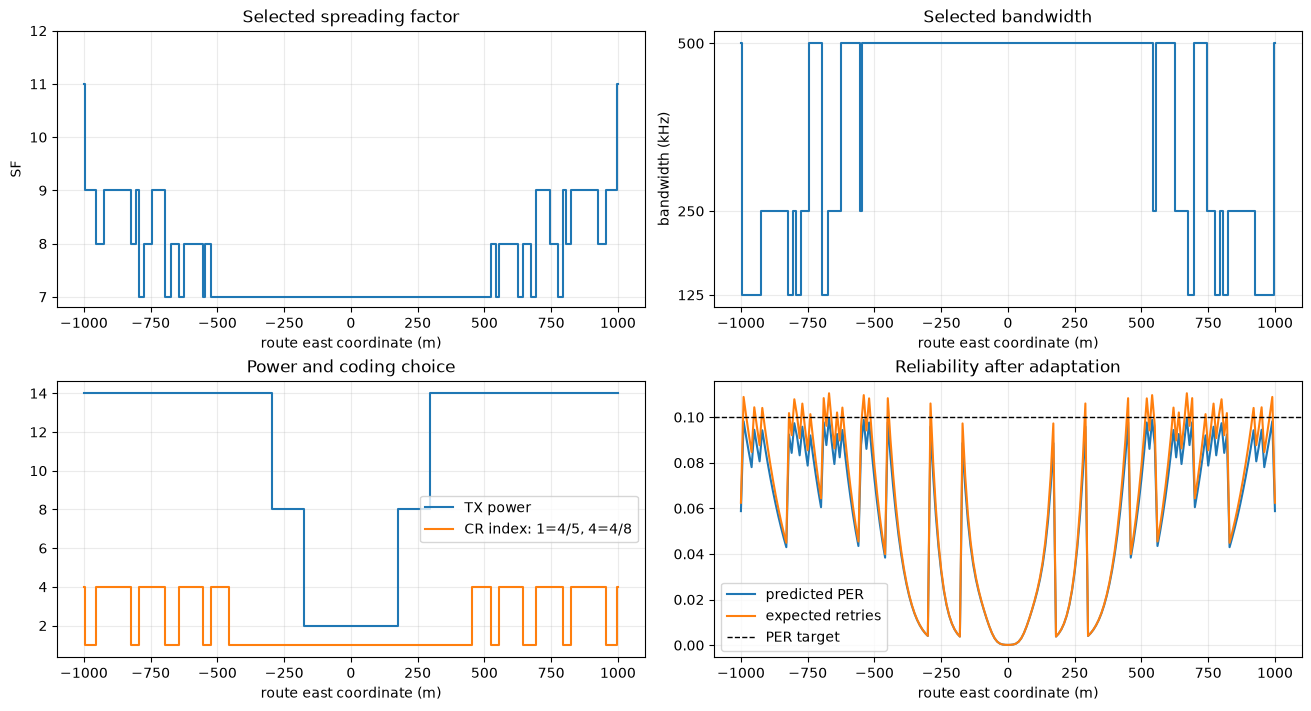

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
axes[0, 0].step(ROUTE_X_M, selected_sf, where="mid")
axes[0, 0].set(title="Selected spreading factor", xlabel="route east coordinate (m)", ylabel="SF", yticks=np.arange(7, 13))

axes[0, 1].step(ROUTE_X_M, selected_bw_khz, where="mid")
axes[0, 1].set(title="Selected bandwidth", xlabel="route east coordinate (m)", ylabel="bandwidth (kHz)", yticks=(125, 250, 500))

axes[1, 0].step(ROUTE_X_M, selected_tx_dbm, where="mid", label="TX power")
axes[1, 0].step(ROUTE_X_M, selected_cr, where="mid", label="CR index: 1=4/5, 4=4/8")
axes[1, 0].set(title="Power and coding choice", xlabel="route east coordinate (m)")
axes[1, 0].legend()

axes[1, 1].plot(ROUTE_X_M, selected_per, label="predicted PER")
axes[1, 1].plot(ROUTE_X_M, selected_attempts - 1, label="expected retries")
axes[1, 1].axhline(TARGET_PER, color="black", linestyle="--", linewidth=1, label="PER target")
axes[1, 1].set(title="Reliability after adaptation", xlabel="route east coordinate (m)")
axes[1, 1].legend()
plt.show()


## 5. Compare against one fixed field configuration

The planned field baseline is SF7, 125 kHz, CR4/5, and 14 dBm. We compare its predicted reliability with the adaptive teaching policy. This is a paired model comparison along one route, not evidence that adaptation is required in the real campaign.


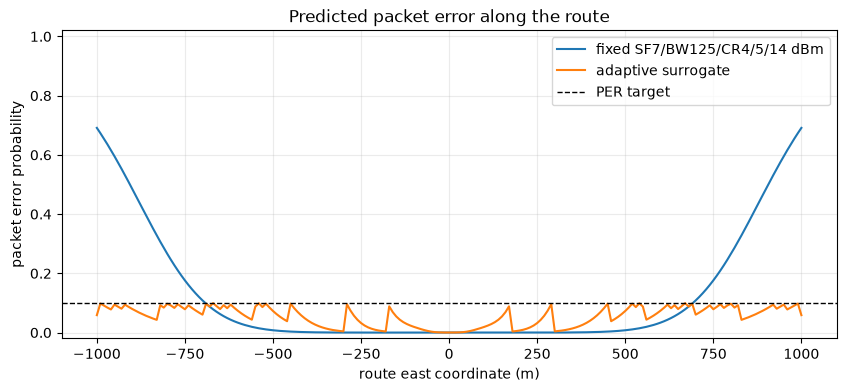

Fixed-policy mean predicted PER: 0.126
Adaptive mean predicted PER:     0.056
Fixed expected total airtime:    12.97 s
Adaptive expected total airtime: 9.59 s


In [6]:
fixed = evaluate_configuration(path_loss_db, 7, 125e3, 1, 14.0)
adaptive_airtime_s = np.sum([item["airtime_s"] * item["expected_attempts"] for item in selected])
fixed_airtime_s = np.sum(fixed["airtime_s"] * fixed["expected_attempts"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ROUTE_X_M, fixed["per"], label="fixed SF7/BW125/CR4/5/14 dBm")
ax.plot(ROUTE_X_M, selected_per, label="adaptive surrogate")
ax.axhline(TARGET_PER, color="black", linestyle="--", linewidth=1, label="PER target")
ax.set(title="Predicted packet error along the route", xlabel="route east coordinate (m)", ylabel="packet error probability", ylim=(-0.02, 1.02))
ax.legend()
plt.show()

print(f"Fixed-policy mean predicted PER: {np.mean(fixed['per']):.3f}")
print(f"Adaptive mean predicted PER:     {np.mean(selected_per):.3f}")
print(f"Fixed expected total airtime:    {fixed_airtime_s:.2f} s")
print(f"Adaptive expected total airtime: {adaptive_airtime_s:.2f} s")


### Airtime saved is not automatically battery energy saved

For independent retries under a fixed link, mean attempts per success are $1/(1-PER)$. Estimate transmitter battery energy using
$$E_{\mathrm{TX,delivery}}=\left(P_{\mathrm{circuit}}+P_{\mathrm{RF}}/\eta_{\mathrm{PA}}\right)\frac{T_{\mathrm{air}}}{1-PER}.$$
The **illustrative** circuit power (15 mW) and PA efficiency (25%) below are editable assumptions, not SX1262 measurements. This excludes startup, sensing, idle listening, ACKs, sleep energy, finite retry limits, and UAV propulsion. Retries must fit inside the contact window and see a sufficiently stable channel. The controller minimizes nominal airtime among feasible configurations; the energy plot is an evaluation, not an energy-optimality claim. LoRa is attractive when sensors can sleep most of the time and transmit small reports.

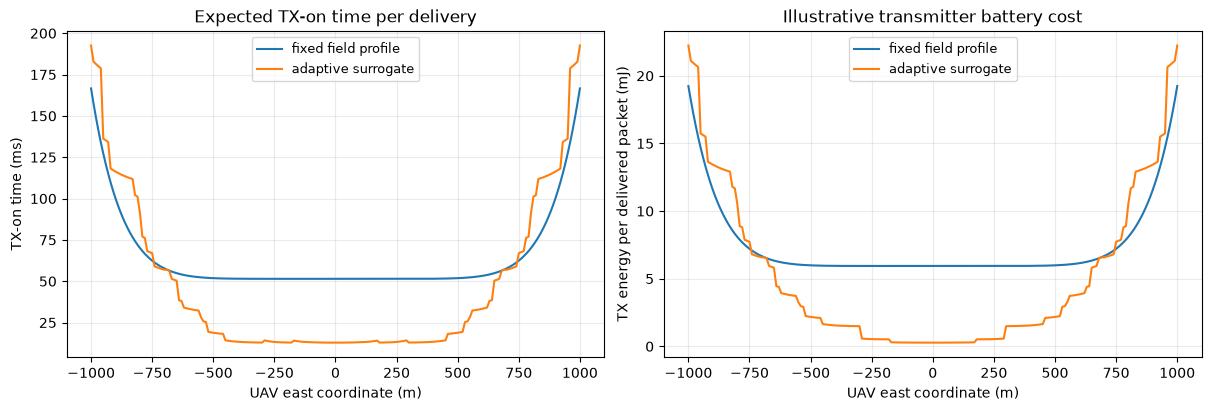

In [7]:
CIRCUIT_POWER_W = 0.015
PA_EFFICIENCY = 0.25
selected_airtime_s = np.array([item['airtime_s'] for item in selected])
adaptive_tx_on_s = selected_airtime_s * selected_attempts
fixed_tx_on_s = fixed['airtime_s'] * fixed['expected_attempts']
adaptive_dc_power_w = CIRCUIT_POWER_W + 10 ** ((selected_tx_dbm - 30) / 10) / PA_EFFICIENCY
fixed_dc_power_w = CIRCUIT_POWER_W + 10 ** ((14.0 - 30) / 10) / PA_EFFICIENCY
adaptive_energy_j = adaptive_dc_power_w * adaptive_tx_on_s
fixed_energy_j = fixed_dc_power_w * fixed_tx_on_s
assert np.all(adaptive_energy_j >= 10 ** ((selected_tx_dbm - 30) / 10) * selected_airtime_s)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, adaptive_values, fixed_values in zip(axes, (1e3 * adaptive_tx_on_s, 1e3 * adaptive_energy_j), (1e3 * fixed_tx_on_s, 1e3 * fixed_energy_j)):
    ax.plot(ROUTE_X_M, fixed_values, label='fixed field profile')
    ax.plot(ROUTE_X_M, adaptive_values, label='adaptive surrogate')
    ax.set(xlabel='UAV east coordinate (m)')
    ax.legend(fontsize=9)
axes[0].set(title='Expected TX-on time per delivery', ylabel='TX-on time (ms)')
axes[1].set(title='Illustrative transmitter battery cost', ylabel='TX energy per delivered packet (mJ)')
plt.show()

## Takeaways

- Link adaptation is a constrained decision problem, not simply 'increase SF when RSS is low.'
- Bandwidth changes noise power and airtime; coding changes overhead and robustness; transmit power changes margin and energy.
- Expected retries can erase an apparently fast configuration's airtime advantage.
- A controller should include uncertainty margin and avoid rapid configuration flapping; this notebook selects independently at each position only to expose the mechanism.
- Replace the log-distance channel, required-SNR table, coding allowance, and logistic PER curve with calibrated RT and packet measurements before deployment.
- Regional channel, bandwidth, EIRP, and access rules must be checked separately.


## Focused references

- Semtech [SX1261/2 datasheet](../../../ref/semtech-sx1261-sx1262-datasheet-2024.pdf): packet airtime, sensitivity test conditions, and supply-current tables for replacing the surrogate and energy assumptions.
- L. Amichi et al., [Joint Allocation Strategies of Power and Spreading Factors with Imperfect Orthogonality in LoRa Networks](https://arxiv.org/abs/1904.11303): research on throughput, fairness, power, and SF allocation. Its optimizer is not implemented here.